# Qiskit Fall Fest 2026 — Challenge 2: Make the Quantum Coin Biased
**IBM Quantum | Vishnu Institute of Technology**

## Objective
Use a single-qubit Qiskit circuit to make measurement outcomes `0` and `1` occur at different rates. Run each experiment for 100 shots, inspect the counts and histograms, and explain how gates change the probabilities.

**Design constraints met:** exactly 1 qubit, measurement included, at most 4 gates before measurement (every circuit here uses only 2), Qiskit only, 100 shots per experiment.

## 1. Setup
Install the required packages if they are not already available in your environment.

In [1]:
%pip install -q qiskit qiskit-aer matplotlib pylatexenc

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

SHOTS = 100
simulator = AerSimulator()


def run_circuit(qc, shots=SHOTS):
    """Run a circuit on the simulator and return the measurement counts."""
    compiled = transpile(qc, simulator)
    return simulator.run(compiled, shots=shots).result().get_counts()


def predicted_p0(theta):
    """Theoretical P(0) for the circuit H -> RY(theta) -> measure.
    H takes |0> to the Bloch angle pi/2, RY(theta) adds theta, and
    P(0) = cos^2(total_angle / 2)."""
    return float(np.cos((np.pi / 2 + theta) / 2) ** 2)


def show_summary(label, counts, predicted_zero=None):
    zeros = counts.get('0', 0)
    ones = counts.get('1', 0)
    total = sum(counts.values())
    line = f'{label}: 0 = {zeros} ({zeros/total:.1%}), 1 = {ones} ({ones/total:.1%}), total = {total}'
    if predicted_zero is not None:
        line += f'  |  predicted: 0 = {predicted_zero:.1%}, 1 = {1 - predicted_zero:.1%}'
    print(line)


print(f'Setup complete: {SHOTS} shots per circuit.')

Setup complete: 100 shots per circuit.


## 2. Main experiment — make `0` more likely

**Prediction before running:** Applying an H gate and then an RY rotation of `-π/3` makes the probability of `0` larger than the probability of `1`.

- H takes the qubit to the equator of the Bloch sphere (rotation angle π/2).
- RY(-π/3) subtracts π/3, so the total angle is π/6.
- P(0) = cos²(π/12) ≈ **93.3%** and P(1) = sin²(π/12) ≈ **6.7%**.

So in 100 shots I expect roughly 93 zeros and 7 ones. The circuit uses 2 gates before measurement, within the limit of 4.

Circuit — bias toward 0:


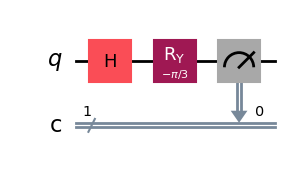

In [3]:
theta_zero = -np.pi / 3

qc_zero_biased = QuantumCircuit(1, 1)       # qubit starts in |0>
qc_zero_biased.h(0)
qc_zero_biased.ry(theta_zero, 0)
qc_zero_biased.measure(0, 0)

print('Circuit — bias toward 0:')
display(qc_zero_biased.draw('mpl'))

Observed counts: {'1': 9, '0': 91}


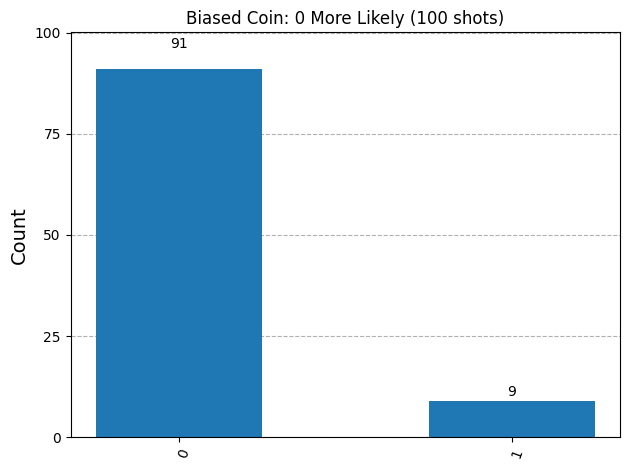

In [4]:
counts_zero = run_circuit(qc_zero_biased)
print('Observed counts:', counts_zero)
display(plot_histogram(counts_zero, title='Biased Coin: 0 More Likely (100 shots)'))

## 3. Bonus — make `1` more likely

**Prediction before running:** Applying an H gate and then an RY rotation of `+π/3` makes `1` more likely.

- H gives the rotation angle π/2.
- RY(+π/3) adds π/3, so the total angle is 5π/6.
- P(1) = sin²(5π/12) ≈ **93.3%** and P(0) = cos²(5π/12) ≈ **6.7%**.

This is the mirror image of the first circuit. (Note: X followed by RY(+π/3) would *not* work here, since it gives a total angle of 4π/3 and only 75% for `1`.)

Circuit — bias toward 1:


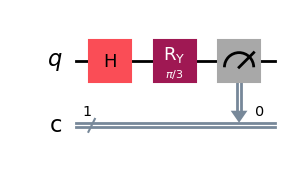

In [5]:
theta_one = np.pi / 3

qc_one_biased = QuantumCircuit(1, 1)
qc_one_biased.h(0)
qc_one_biased.ry(theta_one, 0)
qc_one_biased.measure(0, 0)

print('Circuit — bias toward 1:')
display(qc_one_biased.draw('mpl'))

Observed counts: {'1': 95, '0': 5}


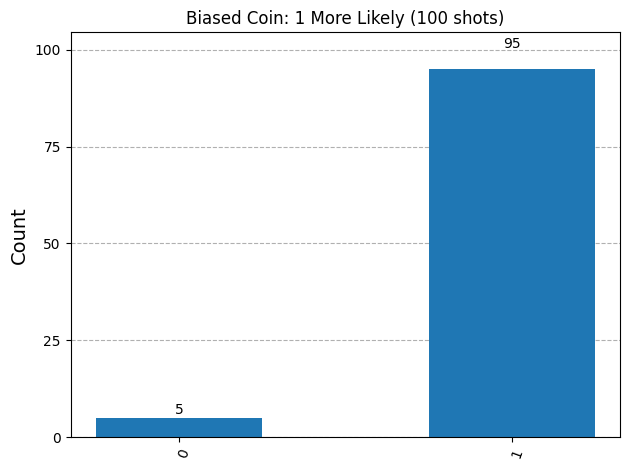

In [6]:
counts_one = run_circuit(qc_one_biased)
print('Observed counts:', counts_one)
display(plot_histogram(counts_one, title='Biased Coin: 1 More Likely (100 shots)'))

## 4. Compare the two bonus histograms
Both circuits are shown on one histogram. The two bars swap sides: the first circuit favors `0` and the second favors `1`.

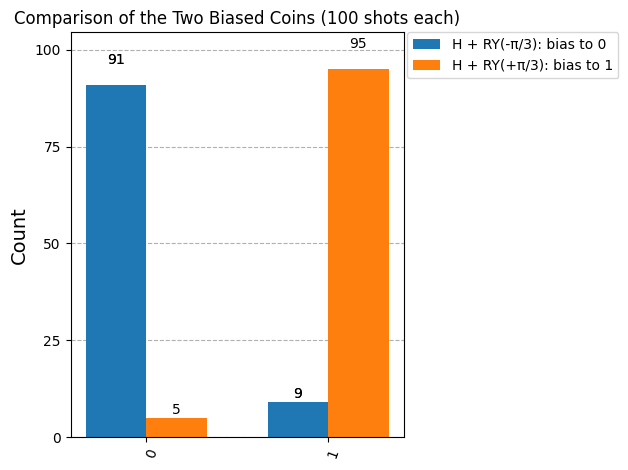

In [7]:
display(plot_histogram(
    [counts_zero, counts_one],
    legend=['H + RY(-π/3): bias to 0', 'H + RY(+π/3): bias to 1'],
    title='Comparison of the Two Biased Coins (100 shots each)'
))

## 5. Different degrees of bias
The challenge asks for different degrees of bias. Here the same circuit (H followed by RY(θ)) is run for several values of θ. A more negative θ pushes the qubit closer to `|0⟩`, so the bias toward `0` grows.

| θ | Total rotation | Predicted P(0) |
|---|---|---|
| 0 | π/2 | 50.0% (fair coin) |
| -π/12 | 5π/12 | ≈ 62.9% |
| -π/6 | π/3 | 75.0% |
| -π/3 | π/6 | ≈ 93.3% |
| -π/2 | 0 | 100.0% |

theta =      0: 0 = 41 (41.0%), 1 = 59 (59.0%), total = 100  |  predicted: 0 = 50.0%, 1 = 50.0%
theta =  -π/12: 0 = 63 (63.0%), 1 = 37 (37.0%), total = 100  |  predicted: 0 = 62.9%, 1 = 37.1%


theta =   -π/6: 0 = 73 (73.0%), 1 = 27 (27.0%), total = 100  |  predicted: 0 = 75.0%, 1 = 25.0%
theta =   -π/3: 0 = 95 (95.0%), 1 = 5 (5.0%), total = 100  |  predicted: 0 = 93.3%, 1 = 6.7%


theta =   -π/2: 0 = 100 (100.0%), 1 = 0 (0.0%), total = 100  |  predicted: 0 = 100.0%, 1 = 0.0%


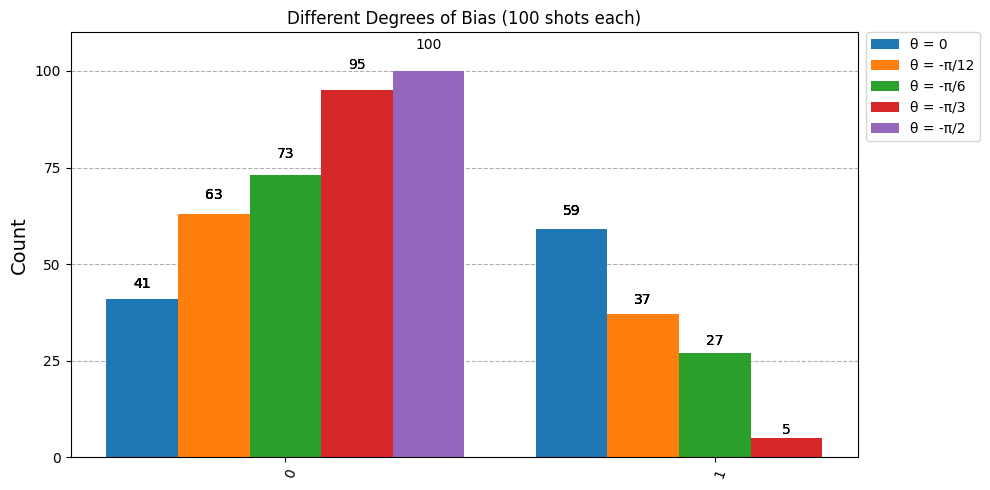

In [8]:
thetas = [
    (0,           '0'),
    (-np.pi / 12, '-π/12'),
    (-np.pi / 6,  '-π/6'),
    (-np.pi / 3,  '-π/3'),
    (-np.pi / 2,  '-π/2'),
]

bias_counts = []
for theta, name in thetas:
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.ry(theta, 0)
    qc.measure(0, 0)
    counts = run_circuit(qc)
    bias_counts.append(counts)
    show_summary(f'theta = {name:>6}', counts, predicted_p0(theta))

display(plot_histogram(
    bias_counts,
    legend=[f'θ = {name}' for _, name in thetas],
    title='Different Degrees of Bias (100 shots each)',
    figsize=(10, 5)
))

## 6. Compare predictions with the observed results
The cell below prints the observed counts next to the predicted percentages for the two main circuits. Because only 100 shots are used, the observed numbers will differ a little from the theory from run to run (typically by a few counts).

In [9]:
show_summary('Circuit biased toward 0 (H + RY(-π/3))', counts_zero, predicted_p0(theta_zero))
show_summary('Circuit biased toward 1 (H + RY(+π/3))', counts_one, predicted_p0(theta_one))

zero_obs = counts_zero.get('0', 0)
one_obs = counts_one.get('1', 0)
print()
print(f'Bias-to-0 circuit: observed {zero_obs} zeros out of {SHOTS}; predicted about 93. '
      f'Difference: {abs(zero_obs - 93.3):.1f} counts.')
print(f'Bias-to-1 circuit: observed {one_obs} ones out of {SHOTS}; predicted about 93. '
      f'Difference: {abs(one_obs - 93.3):.1f} counts.')
print('Both circuits matched their predicted bias direction:',
      zero_obs > SHOTS / 2 and one_obs > SHOTS / 2)

Circuit biased toward 0 (H + RY(-π/3)): 0 = 91 (91.0%), 1 = 9 (9.0%), total = 100  |  predicted: 0 = 93.3%, 1 = 6.7%
Circuit biased toward 1 (H + RY(+π/3)): 0 = 5 (5.0%), 1 = 95 (95.0%), total = 100  |  predicted: 0 = 6.7%, 1 = 93.3%

Bias-to-0 circuit: observed 91 zeros out of 100; predicted about 93. Difference: 2.3 counts.
Bias-to-1 circuit: observed 95 ones out of 100; predicted about 93. Difference: 1.7 counts.
Both circuits matched their predicted bias direction: True


## 7. Explanation — how the gates changed the distribution

- A qubit starts in `|0⟩`, so measuring it right away would always give `0`.
- The **H gate** moves it to an equal superposition, which gives a fair coin (about 50% `0` and 50% `1`).
- The **RY(θ) gate** rotates the state further around the Y axis. A negative angle rotates it back toward `|0⟩`, so `0` becomes more likely. A positive angle rotates it toward `|1⟩`, so `1` becomes more likely.
- The size of the angle sets the degree of bias, as the table in section 5 shows. θ = 0 gives a fair coin, and larger angles give stronger bias.
- The measurements come from only 100 shots, so the observed percentages are close to, but not exactly equal to, the theoretical probabilities.

## 8. Challenge question — answer

**How can quantum gates change the probability of obtaining 0 or 1 when a qubit is measured?**

Quantum gates transform a qubit's quantum state and change the probability amplitudes of `|0⟩` and `|1⟩`. The probability of measuring each result is the squared magnitude of its amplitude. Therefore, by choosing different gates and rotation angles, we can make `0` or `1` more likely. A Hadamard gate creates equal probabilities from `|0⟩`, while suitable additional gates such as RY(θ) can bias the measurement toward either outcome, and the angle θ controls how strong the bias is.